# Hospital Readmission Prediction Project: Initial EDA


### Author:  Ari M.


### Purpose & Goal:
### Initial exploratory data analysis (EDA) of the diabetes hospital dataset. 
### This notebook mostly focuses on understanding the dataset structure, identifying missing values, checking data quality issues, and doing some early exploratory analysis before modeling.


### Dataset used: diabetic_data.csv

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brandao/diabetes")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/brandao/diabetes


In [2]:
import os
import pandas as pd

dataset_path = "/kaggle/input/datasets/brandao/diabetes"

print(os.listdir(dataset_path))

['description.pdf', 'diabetic_data.csv']


In [3]:
# For loading dataset on local system
# import pandas as pd

# df = pd.read_csv("../data/raw/diabetic_data.csv")


# Loading dataset on Kaggle
import os
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/brandao/diabetes/diabetic_data.csv")

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## First Look At The Dataset

In [4]:
df.shape

(101766, 50)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

#### The dataset has a little over 100k hospital encounters and a lot of categorical variables.

#### One thing I noticed immediately is that some columns probably contain missing values encoded as `"?"` instead of actual nulls.

## Replacing Placeholder Missing Values

In [6]:
# Fixing the "?" values
import numpy as np

df = df.replace("?", np.nan)
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Missing Data Check

#### Weight is missing for almost the entire dataset, which is kind of surprising at first.

#### The lab-related columns (`A1Cresult` and `max_glu_serum`) are also mostly empty.

In [7]:
# Exploring missing values further
df.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

## Missing Value Percentages

In [8]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

missing_df

,missing_count,missing_percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636
patient_nbr,0,0.000000


## Thoughts On Missingness

This part took me a bit of back-and-forth. 

A few columns have extremely high missingness:

- weight (~97%)
- max_glu_serum (~95%)
- A1Cresult (~83%)

I considered imputing weight, but with ~97% missingness it would mostly introduce noise rather than signal, so dropping it feels safer.

The lab variables are trickier. Even though they're sparse, they still contain thousands of observations, so I want to keep them for now and revisit later. They could still carry signal for subset of patients. Worth checking whether missing lab tests correlate with severity.

There's also a chance the missingness itself is meaningful. Maybe certain patients only receive these tests under specific conditions.

## Dropping Weight

In [9]:
# Too sparse to be useful
df = df.drop(columns=["weight"])

## Checking Unique Values

In [10]:
# Checking number of unique values per column
df.nunique().sort_values()

citoglipton                      1
examide                          1
tolbutamide                      2
acetohexamide                    2
change                           2
troglitazone                     2
metformin-pioglitazone           2
metformin-rosiglitazone          2
glimepiride-pioglitazone         2
glipizide-metformin              2
diabetesMed                      2
gender                           3
max_glu_serum                    3
readmitted                       3
tolazamide                       3
A1Cresult                        3
miglitol                         4
insulin                          4
rosiglitazone                    4
pioglitazone                     4
acarbose                         4
metformin                        4
repaglinide                      4
nateglinide                      4
glimepiride                      4
glyburide                        4
chlorpropamide                   4
glipizide                        4
glyburide-metformin 

#### Some columns have almost no variability at all.

#### That usually means they won't contribute much to modeling.

In [11]:
df.nunique().sort_values().head(10)

citoglipton                 1
examide                     1
tolbutamide                 2
acetohexamide               2
change                      2
troglitazone                2
metformin-pioglitazone      2
metformin-rosiglitazone     2
glimepiride-pioglitazone    2
glipizide-metformin         2
dtype: int64

## Low Variance Columns

#### `examide` and `citoglipton` only contain a single value (`"No"`), so they don't really carry information.

In [12]:
df["examide"].head(10)

0    No
1    No
2    No
3    No
4    No
5    No
6    No
7    No
8    No
9    No
Name: examide, dtype: object

In [13]:
df["citoglipton"].head(10)

0    No
1    No
2    No
3    No
4    No
5    No
6    No
7    No
8    No
9    No
Name: citoglipton, dtype: object

In [14]:
df = df.drop(columns=["examide", "citoglipton"])

## A Few Quick Category Checks

In [15]:
df["medical_specialty"].value_counts().head(10)

medical_specialty
InternalMedicine              14635
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Radiologist                    1140
Pulmonology                     871
Name: count, dtype: int64

#### Internal medicine and emergency/trauma seem to dominate the specialty categories.

In [16]:
df["diag_1"].dropna().sample(10, random_state=42)

46722      599
23694    250.7
36555      414
42584      577
40747      428
93621      434
91781      511
74808      784
92435      413
70083      410
Name: diag_1, dtype: object

In [17]:
df[["diag_1", "diag_2", "diag_3"]].sample(10, random_state=42)

,diag_1,diag_2,diag_3
35956,250.8,599,263
60927,780,427,E941
79920,715,733,724
50078,494,277,117
44080,403,584,428
4727,162,250,NaN
29944,531,250.41,403
84575,820,70,276
59479,486,453,255
56742,250.8,414,294


#### These diagnosis fields are messier than I expected, lots of mixed formatting and high cardinality. * There are hundreds of unique values. I’ll probably need grouping or encoding strategies before modeling.

## Race Distribution

In [18]:
df["race"].value_counts(normalize=True) * 100

race
Caucasian          76.486788
AfricanAmerican    19.307891
Hispanic            2.047380
Other               1.513674
Asian               0.644266
Name: proportion, dtype: float64

#### Most patients in the dataset are listed as Caucasian, followed by African American patients.

## Readmission Target Variable

In [19]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

#### The original target has 3 categories:

#### - `<30`
#### - `>30`
#### - `NO`

#### For this project, I'm mainly interested in predicting whether a patient was readmitted within 30 days.

## Creating Binary Target

In [20]:
df["readmitted_30"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

#### I’m simplifying this to a binary target for the first modeling pass.

#### - `1` = readmitted within 30 days
#### - `0` = not readmitted within 30 days

In [21]:
df["readmitted_30"].value_counts()

readmitted_30
0    90409
1    11357
Name: count, dtype: int64

In [22]:
# Calculating readmission rate within 30 days
df["readmitted_30"].mean()

np.float64(0.11159915885462728)

## Readmission Rate

#### Looks like around 11% of encounters resulted in readmission within 30 days.

#### So the dataset is somewhat imbalanced, which I'll probably need to account for later during modeling.

## Demographic Exploration

### Gender

In [23]:
df.groupby("gender")["readmitted_30"].mean()

gender
Female             0.112452
Male               0.110615
Unknown/Invalid    0.000000
Name: readmitted_30, dtype: float64

In [24]:
df["gender"].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

#### There are only 3 records labeled as `Unknown/Invalid`, so I wouldn't read too much into that category.

### Race

In [25]:
df.groupby("race")["readmitted_30"].mean()

race
AfricanAmerican    0.112181
Asian              0.101404
Caucasian          0.112906
Hispanic           0.104075
Other              0.096282
Name: readmitted_30, dtype: float64

#### The readmission rates across race categories are fairly similar from this quick check.

#### Nothing jumps out as dramatically different yet.

### Age Groups

In [26]:
df.groupby("age")["readmitted_30"].mean().sort_values()

age
[0-10)      0.018634
[10-20)     0.057887
[50-60)     0.096662
[40-50)     0.106040
[90-100)    0.110992
[60-70)     0.111284
[30-40)     0.112318
[70-80)     0.117731
[80-90)     0.120835
[20-30)     0.142426
Name: readmitted_30, dtype: float64

In [27]:
df["age"].value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

#### Older age groups generally show higher readmission rates, which is more or less what I expected.

#### But one thing that surprised me though was the 20–30 group is oddly high, which doesn’t immediately make sense. Could be small sample noise or some underlying subgroup effect. Worth revisiting later.

## Prior Healthcare Utilization

In [28]:
df[[
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]].describe()

,number_outpatient,number_emergency,number_inpatient
count,101766.000000,101766.000000,101766.000000
mean,0.369357,0.197836,0.635566
std,1.267265,0.930472,1.262863
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000
max,42.000000,76.000000,21.000000


In [29]:
df.groupby("readmitted_30")[[
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]].mean()

,number_outpatient,number_emergency,number_inpatient
readmitted_30,,,
0,0.360871,0.177803,0.561648
1,0.436911,0.357313,1.224003


#### Prior inpatient utilization looks promising, although I’d want to verify this holds once other variables are controlled for.

#### Emergency visits also show a pretty clear difference between the groups.

#### These variables already look more useful than some of the demographic features.

## Length Of Stay

In [30]:
df.groupby("readmitted_30")["time_in_hospital"].mean()

readmitted_30
0    4.349224
1    4.768249
Name: time_in_hospital, dtype: float64

<Axes: xlabel='readmitted_30'>

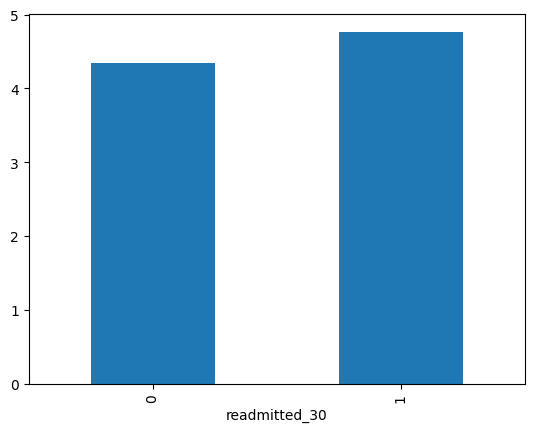

In [31]:
df.groupby("readmitted_30")["time_in_hospital"].mean().plot(kind="bar")

#### Patients who were readmitted stayed slightly longer on average.

#### The difference isn't huge, but longer stays could still reflect higher patient complexity overall.

In [32]:
df.groupby("readmitted_30")["num_medications"].mean()

readmitted_30
0    15.911137
1    16.903143
Name: num_medications, dtype: float64

## Number Of Medications

#### Readmitted patients also received slightly more medications on average.

#### Again, not a massive difference by itself, but probably still useful combined with other variables.

## Saving Cleaned Dataset

In [33]:
# On Kaggle
df.to_csv("/kaggle/working/diabetic_cleaned.csv", index=False)

# On local system
# df.to_csv("../data/processed/diabetic_cleaned.csv", index=False)

print("Saved File diabetic_cleaned.csv")

Saved File diabetic_cleaned.csv


## Final Notes

This first pass through the dataset helped me understand both the structure of the data and some of the main preprocessing challenges before modeling.

Main things I noticed:
- a lot of categorical variables
- several highly sparse columns
- class imbalance in the target
- diagnosis fields with very high cardinality

A few variables already seem potentially important for predicting readmission:
- prior inpatient visits
- emergency visits
- number of medications
- length of stay

At least from these simple grouped averages, demographics don’t seem especially predictive on their own, though interactions could still matter later.

There are still quite a few things I'd want to improve before building models:
- handling sparse lab variables
- encoding diagnosis codes
- feature engineering
- dealing with class imbalance
- checking correlations/interactions between variables

Next step will probably be building a baseline classification model and seeing which features actually contribute useful predictive signal.